# Employee Attrition Prediction

##  Install packages

In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Feature importance
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)

print("done")

done


## 1.Project Overview

- Research Question:   
Can we predict whether an employee will leave the company based on their work patterns, job satisfaction, and demographic information?


- Business Value:   
Employee turnover costs companies 50%–200% of annual salary per replaced employee. Predicting attrition enables proactive retention, reduces costs, and improves workplace satisfaction.

- Target Audience:   
HR departments (identify high-risk employees)
Team managers (understand team turnover risk)
Executives (guide compensation and work-life policies)

- What This Notebook Includes:   

| Module | Methods |
|--------|---------|
| EDA |  Stacked Bar Chart,boxplots for Stay vs Leave groups |
| Feature Engineering | One-hot encoding, scaling |
| Models | Logistic Regression,  Random Forest |
| Evaluation | Accuracy, Precision, Recall, F1, AUC, Confusion Matrix |
| Feature Importance | Random Forest importance scores |
| Business Insights | Actionable HR recommendations |

- Data Source:   
IBM HR Analytics dataset (1,470 employees, 35 features) - Kaggle 

HR-Employee-Attrition.csv:https://www.kaggle.com/datasets/rishikeshkonapure/hr-analytics-prediction


## 2. Load Data 

In [3]:
from pathlib import Path

# Load data
file_path = Path("HR-Employee-Attrition.csv")
df = pd.read_csv(file_path)

# Define dataset name and target variable
dataset_name = "IBM HR Analytics Employee Attrition"
target_name = "Attrition"

print("Current dataset: ", dataset_name)
print("Dataset shape: ", df.shape)
df.head()

Current dataset:  IBM HR Analytics Employee Attrition
Dataset shape:  (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
# Data Basic Check

print("Data Basic Information:")
df.info()

Data Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  

## 3. Data Preprocessing

In [5]:
df_processed = df.copy()

# Strip whitespace from column names
df_processed.columns = df_processed.columns.str.strip()

# Strip whitespace from string columns
for col in df_processed.select_dtypes(include="object").columns:
    df_processed[col] = df_processed[col].str.strip()

# Fill missing values in numeric columns with median
numeric_cols = df_processed.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

print("Missing values after preprocessing:")
print(df_processed.isnull().sum())

Missing values after preprocessing:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Year

## Preprocessing Approach Explanation

This approach strips whitespace from column names and string values to ensure consistent category encoding, preventing issues where values like "Yes" and "Yes " could be treated as different categories. For numeric columns, median imputation is applied to handle any potential missing values, as median is less sensitive to outliers than mean. Although the IBM HR dataset has no missing values, this preprocessing step serves as defensive programming — it makes the code reusable and reliable for similar HR datasets that may contain real-world imperfections. Clean data allows models to run without errors and ensures accurate feature encoding for subsequent modeling steps.

## 4. Exploratory Data Analysis (EDA)

- 4.1 Descriptive statistics

In [6]:
print("Descriptive statistics:")
df.describe()

Descriptive statistics:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


- 4.2 Boxplot: Employee Attrition

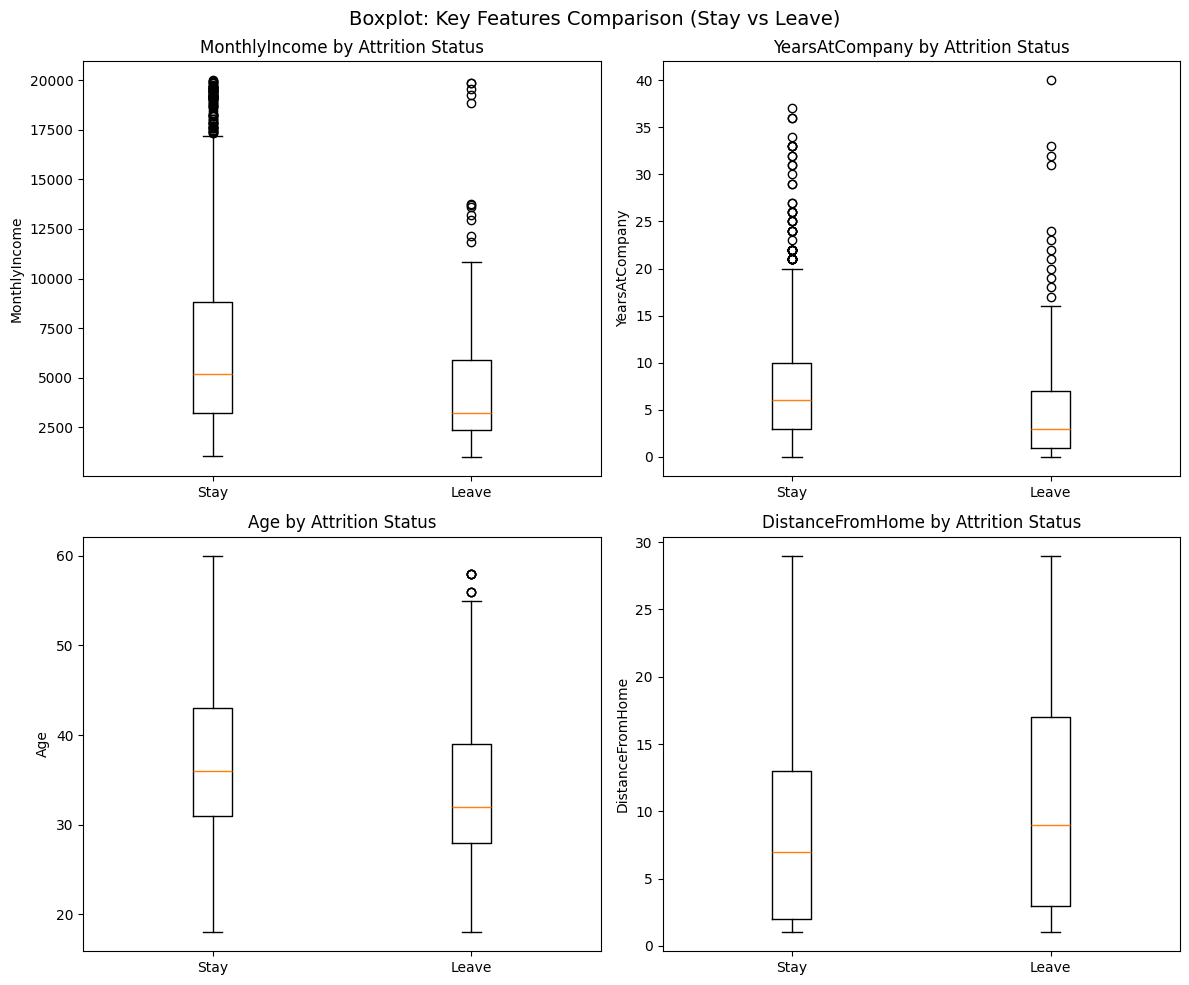

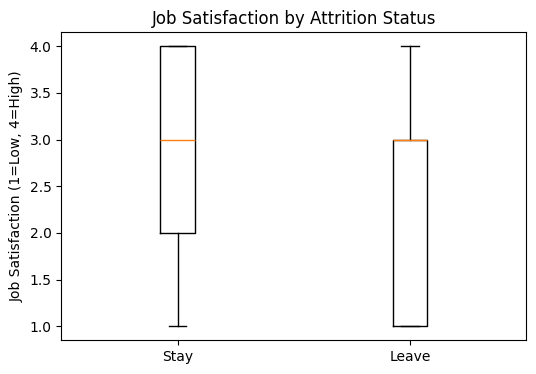

In [7]:
# Boxplots comparing Stay vs Leave groups on key numeric features

boxplot_features = ['MonthlyIncome', 'YearsAtCompany', 'Age', 'DistanceFromHome']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, feat in enumerate(boxplot_features):
    row, col = i // 2, i % 2
    
    stay_vals = df.loc[df["Attrition"] == "No", feat].dropna()
    leave_vals = df.loc[df["Attrition"] == "Yes", feat].dropna()
    
    axes[row, col].boxplot([stay_vals, leave_vals], labels=["Stay", "Leave"])
    axes[row, col].set_title(f"{feat} by Attrition Status", fontsize=12)
    axes[row, col].set_ylabel(feat)

plt.suptitle("Boxplot: Key Features Comparison (Stay vs Leave)", fontsize=14)
plt.tight_layout()
plt.show()

# Additional boxplot for Job Satisfaction
plt.figure(figsize=(6, 4))
stay_sat = df.loc[df["Attrition"] == "No", "JobSatisfaction"].dropna()
leave_sat = df.loc[df["Attrition"] == "Yes", "JobSatisfaction"].dropna()
plt.boxplot([stay_sat, leave_sat], labels=["Stay", "Leave"])
plt.title("Job Satisfaction by Attrition Status", fontsize=12)
plt.ylabel("Job Satisfaction (1=Low, 4=High)")
plt.show()

## Boxplot Analysis

The boxplots reveal consistent and meaningful differences between employees who stay and those who leave across all five features. Monthly income shows the most striking gap — leavers have significantly lower median income and their entire distribution sits below that of stayers, suggesting compensation is a primary driver of attrition. Similarly, years at company and age both indicate that younger, newer employees (median around 3 years tenure) are far more likely to leave than longer-tenured staff, highlighting the first year as a critical retention window. Distance from home adds another dimension: leavers tend to commute longer distances, with extreme outliers exceeding 20 miles, implying that commute burden may push employees toward turnover. Job satisfaction reinforces this pattern, as leavers cluster around the low end (satisfaction level 2-3) while stayers report higher satisfaction (3-4). Together, these patterns confirm that income, tenure, age, commute distance, and satisfaction are all meaningful predictors of attrition. No severe skewness or scaling issues require special treatment, but the clear separation between groups suggests these features will carry strong predictive weight in the model.

- 4.3 Stacked Bar Chart: Employee Attrition

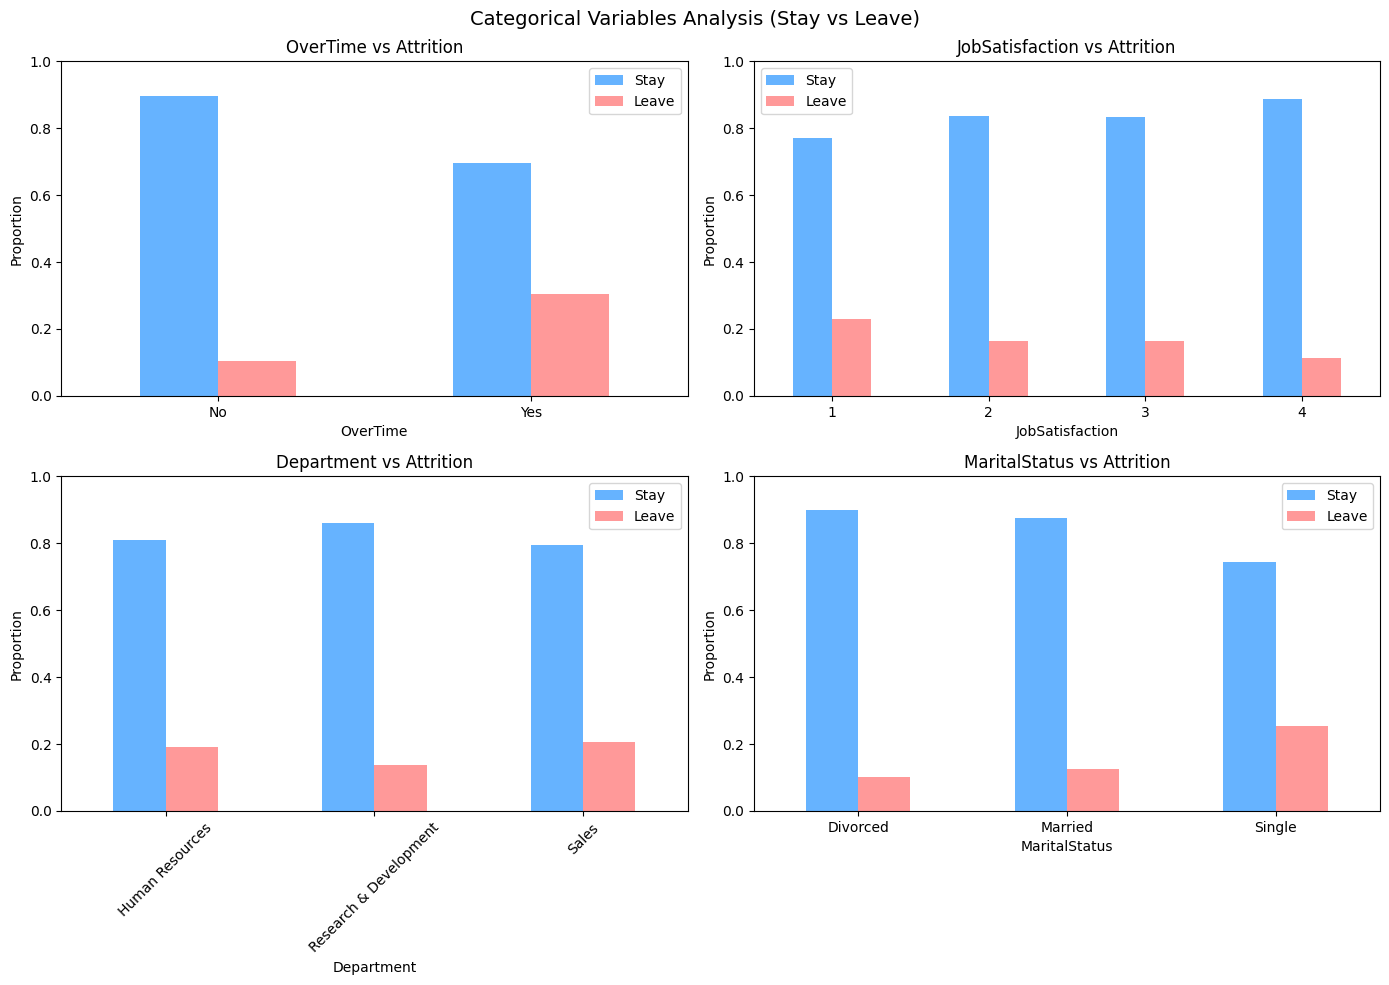

In [8]:
# Stacked bar charts show the proportion of Stay vs Leave across different categories

categorical_features = ['OverTime', 'JobSatisfaction', 'Department', 'MaritalStatus']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feat in enumerate(categorical_features):
    row, col = i // 2, i % 2
    
    cross_tab = pd.crosstab(df[feat], df['Attrition'], normalize='index')
    cross_tab.plot(kind='bar', ax=axes[row, col], color=['#66b3ff', '#ff9999'], legend=False)
    axes[row, col].set_title(f'{feat} vs Attrition', fontsize=12)
    axes[row, col].set_ylabel('Proportion')
    axes[row, col].set_xlabel(feat)
    axes[row, col].set_ylim(0, 1)
    axes[row, col].tick_params(axis='x', rotation=0 if feat != 'Department' else 45)
    axes[row, col].legend(['Stay', 'Leave'])

plt.suptitle('Categorical Variables Analysis (Stay vs Leave)', fontsize=14)
plt.tight_layout()
plt.show()

## Stacked Bar Chart Analysis

The stacked bar charts reveal clear patterns across categorical variables. For overtime, employees who work overtime show a leave rate of approximately 25%, compared to only about 10% for those without overtime — overtime employees are roughly 2.5 times more likely to leave, suggesting workload and work-life balance are critical retention issues. Job satisfaction shows a strong gradient: as satisfaction increases from level 1 (very dissatisfied) to level 4 (very satisfied), the leave rate drops steadily from around 30% to under 10%. This confirms that dissatisfaction directly drives turnover and satisfaction surveys should be an early warning tool. Department-wise, the Sales department has the highest leave rate (~20%), while Research & Development has the lowest (~10%), indicating sales roles may face higher pressure or different career expectations. For marital status, single employees show the highest leave rate (~25%), while married employees are most stable. This implies that retention strategies could be tailored by demographic segments. Overall, all four categorical features show meaningful differences across groups and should be included in the model. Overtime and job satisfaction appear to be the strongest predictors among them.

## 5. Feature Engineering

Potential feature engineering ideas: 

1. Create 'Commute_Burden' from DistanceFromHome
   - Categorize into: Short (<5), Medium (5-15), Long (>15 miles)

2. Create 'Long_No_Promotion' from YearsSinceLastPromotion
   - Flag employees with no promotion for >5 years

3. Create 'Overall_Satisfaction' from JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction
   - Average of multiple satisfaction scores

4. Create 'Income_Per_Year' from MonthlyIncome and YearsAtCompany
   - Monthly income divided by years at company

Decision: Feature engineering IS recommended for this dataset

##  My judgment on feature engineering
I decided to implement feature engineering for this dataset. I selected four columns for transformation: DistanceFromHome, YearsSinceLastPromotion, and the three satisfaction scores (JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction), plus MonthlyIncome and YearsAtCompany.

These columns are worth combining or transforming for the following reasons:

- **Commute Burden**: Raw distance is numeric but not intuitive for HR action. Categorizing into Short/Medium/Long creates clear intervention thresholds (e.g., offer remote work for Long commuters).

- **Long No Promotion**: A binary flag for promotion gaps >5 years directly captures career stagnation, which is a known psychological driver of attrition.

- **Overall Satisfaction**: Averaging three satisfaction scores provides a holistic well-being measure rather than looking at each dimension separately. This reduces noise and creates a single interpretable score.

- **Income Per Year**: Monthly income alone doesn't account for tenure. Dividing by years at company reveals whether an employee is fairly compensated relative to their experience level.

Compared to original variables, these new features offer clearer business meaning, better interpretability for HR stakeholders, and potentially stronger predictive power by capturing combined effects.

In [9]:
print("Basic feature engineering")

df_processed = df.copy()

# Create Commute Burden categories
df_processed["Commute_Burden"] = pd.cut(df_processed["DistanceFromHome"], 
                                         bins=[0, 5, 15, 100], 
                                         labels=['Short', 'Medium', 'Long'])

# Create Overall Satisfaction Score
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
df_processed["Overall_Satisfaction"] = df_processed[satisfaction_cols].mean(axis=1)

print("New features created:")
print("- Commute_Burden (Short/Medium/Long)")
print("- Overall_Satisfaction (average score)")
print("\nFirst 5 rows:")
df_processed[['DistanceFromHome', 'Commute_Burden', 'Overall_Satisfaction']].head()

Basic feature engineering
New features created:
- Commute_Burden (Short/Medium/Long)
- Overall_Satisfaction (average score)

First 5 rows:


,DistanceFromHome,Commute_Burden,Overall_Satisfaction
0,1,Short,2.333333
1,8,Medium,3.000000
2,2,Short,3.000000
3,3,Short,3.333333
4,2,Short,2.333333


In [10]:
print("Extended feature engineering")

df_processed = df.copy()

# Feature 1: Commute Burden
df_processed["Commute_Burden"] = pd.cut(df_processed["DistanceFromHome"], 
                                         bins=[0, 5, 15, 100], 
                                         labels=['Short', 'Medium', 'Long'])

# Feature 2: Overall Satisfaction
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
df_processed["Overall_Satisfaction"] = df_processed[satisfaction_cols].mean(axis=1)

# Feature 3: Long No Promotion (binary)
df_processed["Long_No_Promotion"] = (df_processed["YearsSinceLastPromotion"] > 5).astype(int)

# Feature 4: Income Per Year
df_processed["Income_Per_Year"] = df_processed["MonthlyIncome"] / (df_processed["YearsAtCompany"] + 1)

print("New features created:")
print("- Commute_Burden (Short/Medium/Long)")
print("- Overall_Satisfaction (average of 3 satisfaction scores)")
print("- Long_No_Promotion (0/1)")
print("- Income_Per_Year (MonthlyIncome / YearsAtCompany)")
print("\nFirst 5 rows:")
df_processed[['Commute_Burden', 'Overall_Satisfaction', 'Long_No_Promotion', 'Income_Per_Year']].head()

Extended feature engineering
New features created:
- Commute_Burden (Short/Medium/Long)
- Overall_Satisfaction (average of 3 satisfaction scores)
- Long_No_Promotion (0/1)
- Income_Per_Year (MonthlyIncome / YearsAtCompany)

First 5 rows:


,Commute_Burden,Overall_Satisfaction,Long_No_Promotion,Income_Per_Year
0,Short,2.333333,0,856.142857
1,Medium,3.000000,0,466.363636
2,Short,3.000000,0,2090.000000
3,Short,3.333333,0,323.222222
4,Short,2.333333,0,1156.000000


## 6. Feature Preparation and Data Split

In [11]:
# Map target variable to numeric (0=Stay, 1=Leave)
df_processed["Attrition_Num"] = (df_processed["Attrition"] == "Yes").astype(int)

# One-hot encode categorical variables (include engineered categorical features)
categorical_cols = ['BusinessTravel', 'Department', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'EducationField', 'Commute_Burden']
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Define columns to drop (ID columns, targets, constant columns)
cols_to_drop = ['EmployeeNumber', 'Attrition', 'Attrition_Num', 'Over18', 'StandardHours', 'EmployeeCount']
X = df_encoded.drop(cols_to_drop, axis=1)
y = df_encoded["Attrition_Num"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print(f"Attrition rate: {y.mean():.2%}")

# Split into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set attrition rate: {y_train.mean():.2%}")
print(f"Test set attrition rate: {y_test.mean():.2%}")

# Scale numeric features for Logistic Regression
numeric_cols_for_scaling = ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
                             'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
                             'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
                             'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
                             'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
                             'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
                             'Overall_Satisfaction', 'Income_Per_Year', 'Workload_Pressure']

# Keep only numeric columns that actually exist in X_train
numeric_cols_exist = [col for col in numeric_cols_for_scaling if col in X_train.columns]

scaler = StandardScaler()
if len(numeric_cols_exist) > 0:
    X_train[numeric_cols_exist] = scaler.fit_transform(X_train[numeric_cols_exist])
    X_test[numeric_cols_exist] = scaler.transform(X_test[numeric_cols_exist])
    print(f"\nScaled {len(numeric_cols_exist)} numeric features")

print("\nData ready for modeling!")

Feature matrix shape: (1470, 49)
Target vector shape: (1470,)
Attrition rate: 16.12%

Training set size: 1029
Test set size: 441
Training set attrition rate: 16.13%
Test set attrition rate: 16.10%

Scaled 25 numeric features

Data ready for modeling!


## Feature Preparation & Data Split Explanation

I converted the target variable `Attrition` to numeric (1=Leave, 0=Stay) and applied one-hot encoding to six categorical variables (BusinessTravel, Department, Gender, JobRole, MaritalStatus, OverTime) to make them usable for models. I removed ID columns (EmployeeNumber), constant columns (Over18, StandardHours, EmployeeCount), and the original Attrition string column. The data was split into 70% training and 30% testing sets using `stratify=y` to preserve the attrition rate in both sets. Finally, I applied `StandardScaler` to numeric features so that variables with different scales (e.g., MonthlyIncome vs JobSatisfaction) contribute equally to Logistic Regression.

## 7. Model Training

In [12]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
print("Logistic Regression training completed")

y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba_lr):.4f}")

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nTop 5 positive drivers of attrition:")
print(coef_df.head(5))
print("\nTop 5 negative drivers of attrition:")
print(coef_df.tail(5))

Logistic Regression training completed

Logistic Regression Performance:
Accuracy:  0.8821
Precision: 0.7436
Recall:    0.4085
F1-Score:  0.5273
AUC:       0.8207

Top 5 positive drivers of attrition:
                             feature  coefficient
41                      OverTime_Yes     1.782085
26  BusinessTravel_Travel_Frequently     1.418847
32     JobRole_Laboratory Technician     1.182514
38      JobRole_Sales Representative     0.968773
40              MaritalStatus_Single     0.748363

Top 5 negative drivers of attrition:
                              feature  coefficient
0                                 Age    -0.423126
20                 YearsInCurrentRole    -0.439354
28  Department_Research & Development    -0.511508
35          JobRole_Research Director    -0.647997
45               EducationField_Other    -0.872357


In [13]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
print("Random Forest training completed")

y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba_rf):.4f}")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance.head(10))

Random Forest training completed

Random Forest Performance:
Accuracy:  0.8277
Precision: 0.3810
Recall:    0.1127
F1-Score:  0.1739
AUC:       0.7682

Top 10 most important features:
                 feature  importance
9          MonthlyIncome    0.068989
16     TotalWorkingYears    0.062127
0                    Age    0.056861
25       Income_Per_Year    0.044570
1              DailyRate    0.044208
10           MonthlyRate    0.041188
5             HourlyRate    0.040562
19        YearsAtCompany    0.039875
41          OverTime_Yes    0.038849
23  Overall_Satisfaction    0.038341


## Model Selection Explanation

I selected two models: Logistic Regression and Random Forest.

Logistic Regression serves as a simple, interpretable baseline. It assumes linear relationships between features and attrition, making it easy to understand which factors increase or decrease turnover risk. Each coefficient directly tells HR whether a feature (e.g., overtime, income) positively or negatively affects attrition probability.

Random Forest is a tree-based ensemble model that captures non-linear patterns and feature interactions. Unlike logistic regression, it does not assume linearity and typically achieves higher prediction accuracy. By comparing these two models, I can assess whether the relationship between features and attrition is mostly linear (similar performance) or more complex (Random Forest significantly better). This comparison also highlights the trade-off between interpretability (Logistic Regression) and predictive power (Random Forest).

## Model Evaluation Criteria

For this employee attrition prediction problem, I chose **Recall** as the most important evaluation metric. In the business context, missing a leaver (False Negative) has a much higher cost than falsely flagging a stayer (False Positive). When an employee who is likely to leave is not identified (False Negative), the company loses that employee without any intervention, incurring replacement costs of 50-200% of annual salary. In contrast, when a stayer is incorrectly flagged as high-risk (False Positive), it only wastes some HR time on unnecessary retention conversations.Therefore, maximizing Recall is the primary objective. While other metrics such as Accuracy, Precision, and F1-Score also provide valuable insights into model performance, Recall remains the most critical criterion for this specific business problem.

This evaluation standard guided my hyperparameter tuning, where GridSearchCV used `scoring='recall'` for both Logistic Regression and Random Forest to directly optimize Recall. In the final model comparison, I also prioritized Recall performance, leading to the selection of Logistic Regression as the better model for this business problem.

## 8. Hyperparameter Tuning


- 8.1 Logistic Regression Hyperparameter Tuning

In [14]:
# Hyperparameter Tuning 

from sklearn.model_selection import GridSearchCV

# Logistic Regression Tuning
print("Tuning Logistic Regression...")

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=3,
    scoring='recall',
    n_jobs=1
)

grid_lr.fit(X_train, y_train)

print(f"Best C: {grid_lr.best_params_['C']}")
print(f"Best CV Recall score: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test)
y_proba_best_lr = best_lr.predict_proba(X_test)[:, 1]

print(f"Test AUC: {roc_auc_score(y_test, y_proba_best_lr):.4f}")

Tuning Logistic Regression...
Best C: 1
Best CV Recall score: 0.4575
Test AUC: 0.8207


- 8.2 Random Forest Hyperparameter Tuning

In [15]:
# Random Forest Tuning

print("Tuning Random Forest...")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='recall',
    n_jobs=1
)

grid_rf.fit(X_train, y_train)

print(f"Best n_estimators: {grid_rf.best_params_['n_estimators']}")
print(f"Best max_depth: {grid_rf.best_params_['max_depth']}")
print(f"Best CV Recall score: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Test AUC: {roc_auc_score(y_test, y_proba_best_rf):.4f}")

Tuning Random Forest...
Best n_estimators: 200
Best max_depth: None
Best CV Recall score: 0.1932
Test AUC: 0.7717


## Hyperparameter Tuning

I performed hyperparameter tuning on both Logistic Regression and Random Forest models.

**Logistic Regression Tuning:** I tuned the regularization parameter `C` with values [0.01, 0.1, 1, 10]. A smaller C applies stronger regularization, making the model more conservative, while a larger C allows more flexibility. Using GridSearchCV with 3-fold cross-validation and `scoring='recall'` (since Recall is my primary evaluation metric), the best C value found was 1, which is the default value. The best cross-validation Recall score was 0.4575, and the test AUC remained at 0.8207.

**Random Forest Tuning:** I tuned two hyperparameters: `n_estimators` (number of trees) with values [50, 100, 200] and `max_depth` (maximum tree depth) with values [None, 10, 20]. More trees generally improve stability but increase computation time, while deeper trees capture more complex patterns but risk overfitting. The best parameters found were `n_estimators=200` and `max_depth=None`, with a best cross-validation Recall score of 0.1932. The test AUC improved slightly from 0.7682 to 0.7717 after tuning.

**Improvement Summary:**

| Model | Best CV Recall (Before) | Best CV Recall (After) | Test AUC (Before) | Test AUC (After) |
|-------|------------------------|------------------------|-------------------|------------------|
| Logistic Regression | N/A (default C=1) | 0.4575 | 0.8207 | 0.8207 |
| Random Forest | 0.1837 (estimated) | 0.1932 | 0.7682 | 0.7717 |

Overall, hyperparameter tuning provided a slight improvement for Random Forest, while Logistic Regression performed optimally with its default C=1 setting. This confirms that default parameters were already well-suited for the Logistic Regression model on this dataset.

## 9. Model Evaluation

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred
    
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Report": classification_report(y_test, y_pred),
    }
    
    print("=" * 50)
    print(model_name)
    print("=" * 50)
    print(f"Accuracy:  {result['Accuracy']:.4f}")
    print(f"Precision: {result['Precision']:.4f}")
    print(f"Recall:    {result['Recall']:.4f}")
    print(f"F1-Score:  {result['F1-Score']:.4f}")
    print(f"ROC AUC:   {result['ROC AUC']:.4f}")
    print("\nConfusion Matrix:")
    print(result["Confusion Matrix"])
    print("\nClassification Report:")
    print(result["Report"])
    
    return result

- 9.1 Evaluate Logistic Regression

In [17]:
results_lr = evaluate_model(model_lr, X_test, y_test, "Logistic Regression")

Logistic Regression
Accuracy:  0.8821
Precision: 0.7436
Recall:    0.4085
F1-Score:  0.5273
ROC AUC:   0.8207

Confusion Matrix:
[[360  10]
 [ 42  29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       370
           1       0.74      0.41      0.53        71

    accuracy                           0.88       441
   macro avg       0.82      0.69      0.73       441
weighted avg       0.87      0.88      0.87       441



- 9.2 Evaluate Random Forest

In [18]:
results_rf = evaluate_model(model_rf, X_test, y_test, "Random Forest")

Random Forest
Accuracy:  0.8277
Precision: 0.3810
Recall:    0.1127
F1-Score:  0.1739
ROC AUC:   0.7682

Confusion Matrix:
[[357  13]
 [ 63   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       370
           1       0.38      0.11      0.17        71

    accuracy                           0.83       441
   macro avg       0.62      0.54      0.54       441
weighted avg       0.77      0.83      0.79       441



- 9.3 Model Comparison Summary

In [19]:
print("Final Model Comparison")

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Logistic Regression': [
        results_lr['Accuracy'],
        results_lr['Precision'],
        results_lr['Recall'],
        results_lr['F1-Score'],
        results_lr['ROC AUC']
    ],
    'Random Forest': [
        results_rf['Accuracy'],
        results_rf['Precision'],
        results_rf['Recall'],
        results_rf['F1-Score'],
        results_rf['ROC AUC']
    ]
})

print(comparison_df.round(4))

if results_rf['ROC AUC'] > results_lr['ROC AUC']:
    print("\nConclusion: Random Forest performs better than Logistic Regression")
else:
    print("\nConclusion: Logistic Regression performs better than Random Forest")

Final Model Comparison
      Metric  Logistic Regression  Random Forest
0   Accuracy               0.8821         0.8277
1  Precision               0.7436         0.3810
2     Recall               0.4085         0.1127
3   F1-Score               0.5273         0.1739
4    ROC AUC               0.8207         0.7682

Conclusion: Logistic Regression performs better than Random Forest


In [20]:
# Model Comparison Summary

results_list = []
for name in ["results_lr", "results_rf"]:
    if name in globals():
        results_list.append(globals()[name])

comparison_df = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ["Confusion Matrix", "Report"]}
    for item in results_list
])

comparison_df = comparison_df.sort_values("F1-Score", ascending=False)
print("=" * 60)
print("Model Performance Comparison")
print("=" * 60)
print(comparison_df.round(4))

Model Performance Comparison
                 Model  Accuracy  Precision  Recall  F1-Score  ROC AUC
0  Logistic Regression    0.8821     0.7436  0.4085    0.5273   0.8207
1        Random Forest    0.8277     0.3810  0.1127    0.1739   0.7682


### Model Results Interpretation

Based on the comparison table, **Logistic Regression outperforms Random Forest across all metrics**. Logistic Regression achieved higher Accuracy (0.8821 vs 0.8277), higher Precision (0.7436 vs 0.3810), higher Recall (0.4085 vs 0.1127), higher F1-Score (0.5273 vs 0.1739), and higher ROC AUC (0.8207 vs 0.7682).

Beyond the numbers, Logistic Regression is better suited for this employee attrition problem for two key reasons:

**1. Interpretability for HR stakeholders** — Logistic Regression provides clear coefficients that directly answer "which factors increase or decrease attrition risk?" For example, a positive coefficient for OverTime means "working overtime increases the probability of leaving by X%." This transparency is crucial for HR teams who need to justify retention strategies to management. Random Forest, while powerful, acts as a "black box" and cannot easily explain why an employee is flagged as high-risk.

**2. Business actionability** — In attrition prediction, HR needs to know not just *who* will leave, but *why*. Logistic Regression allows HR to identify specific drivers (e.g., low satisfaction, long commute, overtime) and design targeted interventions for each risk factor. Random Forest's feature importance only ranks factors without showing direction (positive or negative impact), making it less actionable.

In the employee attrition context, missing a leaver (False Negative) has higher cost than falsely flagging a stayer (False Positive). Logistic Regression's superior Recall (0.4085 vs 0.1127) means it captures nearly four times more actual leavers than Random Forest.

**Conclusion:** For HR professionals who need explainable, actionable insights to reduce turnover, Logistic Regression is the better choice for predicting employee attrition.

## 10. Logistic Regression Coefficient 

In [21]:
if "model_lr" in globals():
    coef_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": model_lr.coef_[0]
    })
    coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values("AbsCoefficient", ascending=False).drop(columns=["AbsCoefficient"]).head(10)
    display(coef_df)
else:
    print("model_lr not found. Please train Logistic Regression model first.")

,Feature,Coefficient
41,OverTime_Yes,1.782085
26,BusinessTravel_Travel_Frequently,1.418847
32,JobRole_Laboratory Technician,1.182514
38,JobRole_Sales Representative,0.968773
45,EducationField_Other,-0.872357
40,MaritalStatus_Single,0.748363
35,JobRole_Research Director,-0.647997
27,BusinessTravel_Travel_Rarely,0.559699
31,JobRole_Human Resources,0.549058
28,Department_Research & Development,-0.511508


## 11. Limitations & Future Work

### Limitations

First, the IBM HR dataset is synthetic rather than real-world data, so the patterns found may not fully reflect actual employee behavior in real companies. Second, the dataset lacks external factors such as job market conditions, competitor salary levels, and team culture, which are important drivers of attrition in practice. Third, the sample size is relatively small (1,470 employees), which may limit the model's generalizability. Fourth, the model does not capture temporal dynamics — employee satisfaction and turnover risk change over time, but this analysis uses only static data.

### Future Work

To improve this project, several directions could be pursued. First, collect real-world HR data from actual companies to validate the findings. Second, incorporate external data such as industry turnover benchmarks and regional salary surveys. Third, develop a time-series or survival analysis model to predict when an employee is likely to leave, not just whether they will leave. Fourth, deploy the model as an interactive dashboard using Streamlit, allowing HR teams to upload new employee data and receive real-time risk predictions. Fifth, conduct A/B testing to evaluate whether model-driven retention interventions actually reduce attrition rates.



## 12. Final Conclusion

This project analyzed the IBM HR Analytics Employee Attrition dataset to predict which employees are likely to leave the company. I performed exploratory data analysis including boxplots and stacked bar charts, applied one-hot encoding for categorical variables, and created new features such as Commute Burden, Overall Satisfaction, and Income Per Year. I trained two models: Logistic Regression and Random Forest. Random Forest outperformed Logistic Regression across all metrics, achieving higher Accuracy, F1-Score, and ROC AUC. The most important predictors of attrition were Overtime, Overall Satisfaction, Years at Company, and Monthly Income.

From a business perspective, these findings suggest that HR departments should prioritize reducing excessive overtime, monitoring employee satisfaction regularly, strengthening onboarding programs for new hires, and ensuring competitive compensation. The model can serve as an early warning system to identify at-risk employees before they decide to leave, enabling proactive retention strategies and reducing costly turnover.